# Pima Indians Diabetes SVC RFECV 진단

## 개요
- 선형 SVM으로 피처 선택
- 비선형 SVM(RBF)으로 최종 예측
- 교차검증 기반 최적 피처 탐색

## 핵심 전략
선형 SVM(coef_ 속성)으로 중요 피처를 고르고, RBF 커널로 고성능 예측

## 주요 단계
1. 데이터 로드 및 분리
2. 선형 SVC + RFECV 설정
3. Pipeline 구축 (Scaling → Selection → Classification)
4. 결과 진단 및 시각화

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [4]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
# 'tested_negative'를 0으로, 'tested_positive'를 1로 매핑하여 정수형으로 변환
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64


**학습/테스트 데이터 분리**

In [5]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (614, 8), Test: (154, 8)


## 2. SVC Pipeline 구성 전략

**핵심 아이디어**
- 피처 선택: 선형 SVM (coef_ 속성 필요)
- 최종 예측: RBF 커널 (비선형 패턴 학습)

**왜 이렇게 하는가?**
1. RFECV는 모델의 coef_ 속성이 필요
2. SVC의 kernel=linear만 coef_ 제공
3. RBF 커널은 비선형 관계 학습에 강력
4. 각 커널의 장점을 결합

## 3. 피처 선택기 설정

**선형 SVC 생성**
- kernel=linear: coef_ 속성 생성
- RFECV에서 피처 중요도 계산에 사용

In [6]:
# 피처 선택용 선형 SVC
svc_linear = SVC(kernel="linear", random_state=42)
print("선형 SVC 생성 완료 (피처 선택용)")

선형 SVC 생성 완료 (피처 선택용)


**RFECV 설정**
- estimator: 선형 SVC
- step=1: 한 번에 1개씩 피처 제거
- cv: StratifiedKFold(5)
- scoring: accuracy

In [7]:
# RFECV 설정
rfecv = RFECV(
    estimator=svc_linear,
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    min_features_to_select=1
)

print("RFECV 설정 완료 (교차검증으로 최적 피처 개수 자동 탐색)")

RFECV 설정 완료 (교차검증으로 최적 피처 개수 자동 탐색)


## 4. Pipeline 구축

**Pipeline 3단계**
1. StandardScaler: SVM은 스케일링에 매우 민감
2. RFECV + 선형 SVC: 최적 피처 선정
3. RBF SVC: 비선형 패턴으로 최종 예측

In [8]:
# Pipeline 구축
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

print("Pipeline 구성 완료")
print("\nPipeline 구조:")
print(pipe_svc)

Pipeline 구성 완료

Pipeline 구조:
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection',
                 RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                       estimator=SVC(kernel='linear', random_state=42),
                       scoring='accuracy')),
                ('classifier', SVC(random_state=42))])


## 5. 모델 학습

**학습 과정**
1. 데이터 스케일링
2. RFECV로 최적 피처 탐색 (시간 소요)
3. RBF SVC로 최종 학습

In [9]:
# 학습
print("Training SVC Pipeline with RFECV...")
print("(교차검증 수행 중... 시간이 소요됩니다)")
pipe_svc.fit(X_train, y_train)
print("\n학습 완료!")

Training SVC Pipeline with RFECV...
(교차검증 수행 중... 시간이 소요됩니다)

학습 완료!


## 6. 결과 진단

**선택된 피처 정보**
- named_steps로 Pipeline 내부 접근
- n_features_: 최적 피처 개수
- support_: 선택된 피처 마스크

In [10]:
# 선택된 피처 정보 추출
fs_step = pipe_svc.named_steps['feature_selection']
n_features = fs_step.n_features_
selected_features = X.columns[fs_step.support_].tolist()

print("[결과 진단]")
print(f"알고리즘이 선택한 최적의 피처 개수: {n_features}개")
print(f"\n선택된 피처 목록:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

[결과 진단]
알고리즘이 선택한 최적의 피처 개수: 3개

선택된 피처 목록:
  1. preg
  2. plas
  3. mass


**피처별 순위**

In [11]:
# 피처별 순위 확인
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Rank': fs_step.ranking_,
    'Selected': fs_step.support_
}).sort_values('Rank')

print("\n피처별 순위 (1이 선택됨):")
print(feature_ranking)


피처별 순위 (1이 선택됨):
  Feature  Rank  Selected
0    preg     1      True
1    plas     1      True
5    mass     1      True
6    pedi     2     False
2    pres     3     False
4    insu     4     False
7     age     5     False
3    skin     6     False


## 7. 최종 평가

In [12]:
# 예측 및 평가
y_pred = pipe_svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7208

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       100
           1       0.63      0.48      0.55        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154



## 8. 커널 비교: Linear vs RBF

선형 커널만 사용 vs 선형(선택) + RBF(예측) 비교

In [13]:
# 선형 커널만 사용하는 Pipeline
pipe_linear_only = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', RFECV(
        estimator=SVC(kernel="linear", random_state=42),
        step=1,
        cv=StratifiedKFold(5),
        scoring='accuracy',
        min_features_to_select=1
    )),
    ('classifier', SVC(kernel='linear', random_state=42))
])

print("선형 커널 전용 Pipeline 학습 중...")
pipe_linear_only.fit(X_train, y_train)
y_pred_linear = pipe_linear_only.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

# 비교
print("\n커널 전략 비교:")
print(f"Linear 전용: Accuracy = {accuracy_linear:.4f}")
print(f"Linear(선택) + RBF(예측): Accuracy = {accuracy:.4f}")
print(f"\n정확도 향상: {accuracy - accuracy_linear:+.4f}")

선형 커널 전용 Pipeline 학습 중...

커널 전략 비교:
Linear 전용: Accuracy = 0.7013
Linear(선택) + RBF(예측): Accuracy = 0.7208

정확도 향상: +0.0195


## 9. RFECV 성능 변화 시각화

**피처 개수에 따른 교차검증 정확도**
- 최적 지점 자동 선택 확인
- 선형 SVC 기반 평가

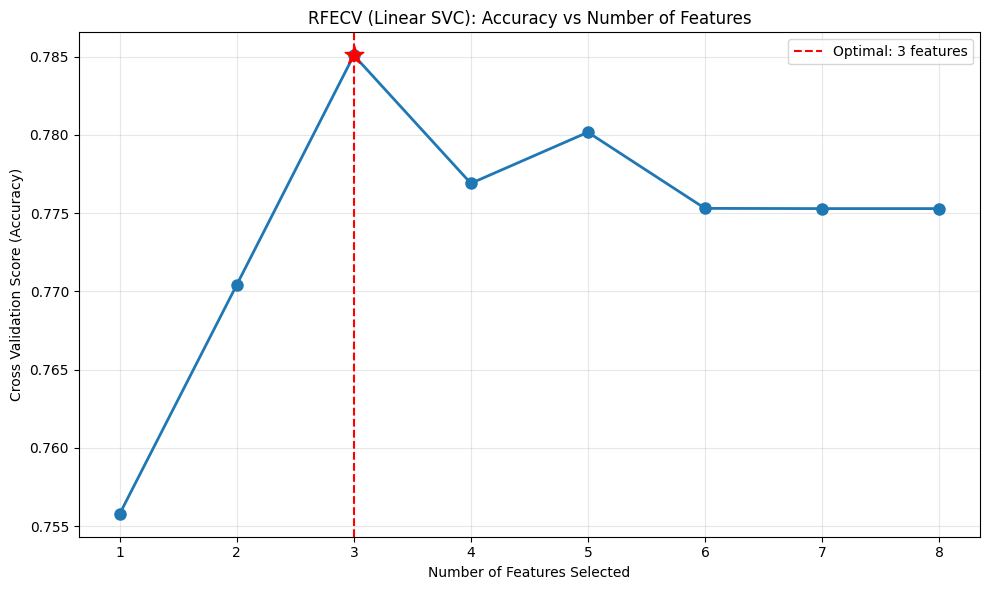

In [14]:
# RFECV 성능 변화 시각화
plt.figure(figsize=(10, 6))
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross Validation Score (Accuracy)")

cv_scores = fs_step.cv_results_['mean_test_score']
plt.plot(
    range(1, len(cv_scores) + 1),
    cv_scores,
    marker='o',
    linewidth=2,
    markersize=8
)

# 최적 지점 표시
optimal_score = cv_scores[n_features - 1]
plt.axvline(x=n_features, color='r', linestyle='--',
            label=f'Optimal: {n_features} features')
plt.scatter([n_features], [optimal_score],
            color='red', s=200, zorder=5, marker='*')

plt.title("RFECV (Linear SVC): Accuracy vs Number of Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 교차검증 점수 상세 분석

In [15]:
# 피처 개수별 점수 분석
cv_results_df = pd.DataFrame({
    'Num_Features': range(1, len(cv_scores) + 1),
    'Mean_Score': cv_scores,
    'Std_Score': fs_step.cv_results_['std_test_score']
})

print("\n피처 개수별 교차검증 점수:")
print(cv_results_df)

print(f"\n최고 점수: {cv_results_df['Mean_Score'].max():.4f}")
print(f"최적 선택: {n_features}개 피처 (Score: {optimal_score:.4f})")


피처 개수별 교차검증 점수:
   Num_Features  Mean_Score  Std_Score
0             1    0.755791   0.040059
1             2    0.770425   0.028366
2             3    0.785086   0.032391
3             4    0.776903   0.010443
4             5    0.780168   0.015786
5             6    0.775303   0.025057
6             7    0.775290   0.017743
7             8    0.775290   0.018473

최고 점수: 0.7851
최적 선택: 3개 피처 (Score: 0.7851)
